In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score

A:OLS for the Runge function
-

Write your own code (using for example the pseudoinverse function pinv from numpy, or
the SVD directly) and perform a standard ordinary least squares regression analysis using
polynomials in x up to order 15 or higher.

In [2]:
def runge(x):
    return (1.0/(1.0+25*x**2))

def design_matrix(x, degree):
    X = np.vander(x, degree +1 , increasing=True)
    return X

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2026)
degrees = np.arange(1,16)

mse_train, mse_test = [], []
R2_train, R2_test = [], []
theta_values = []

for d in degrees:
    scaler = StandardScaler()
    Xtr = design_matrix(x_train, d)
    Xtr_sc = np.copy(Xtr)
    Xtr_sc[:,1:] = scaler.fit_transform(Xtr[:,1:]) 
    Xte = design_matrix(x_test, d)
    Xte_sc = np.copy(Xte)
    Xte_sc[:,1:] = scaler.transform(Xte[:,1:]) 
    theta = np.linalg.lstsq(Xtr_sc, y_train, rcond=None)[0]
    theta_values.append(theta)
    y_train_pred = Xtr_sc @ theta
    y_test_pred = Xte_sc @ theta
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))
    R2_train.append(r2_score(y_train, y_train_pred))
    R2_test.append(r2_score(y_test, y_test_pred))

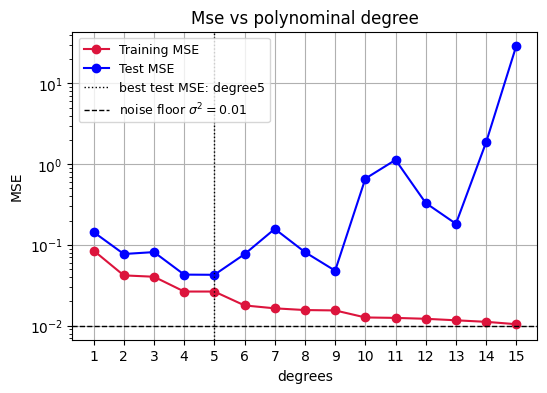

In [ ]:
best_degree = degrees[int(np.argmin(mse_test))]
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_train, "o-", color = "crimson", label = "Training MSE")
plt.plot(degrees, mse_test, "o-", color = "blue", label = "Test MSE")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree{best_degree}")
plt.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
plt.xlabel("degrees"); plt.ylabel("MSE"); plt.xticks(degrees); plt.legend(fontsize=9), plt.grid(True)
plt.title("Mse vs polynominal degree"); plt.yscale("log")


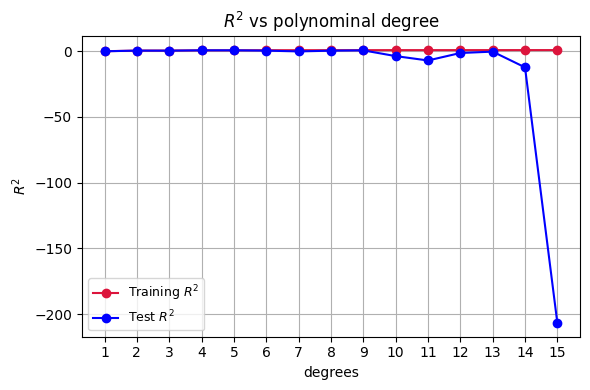

In [4]:
plt.figure(figsize=(6,4)); plt.plot(degrees, R2_train, "o-", color = "crimson", label = "Training $R^2$")
plt.plot(degrees, R2_test, "o-", color = "blue", label = "Test $R^2$")
plt.xlabel("degrees"); plt.ylabel("$R^2$"); plt.xticks(degrees); plt.legend(fontsize=9),
plt.grid(True); plt.title("$R^2$ vs polynominal degree"); plt.tight_layout();plt.show()

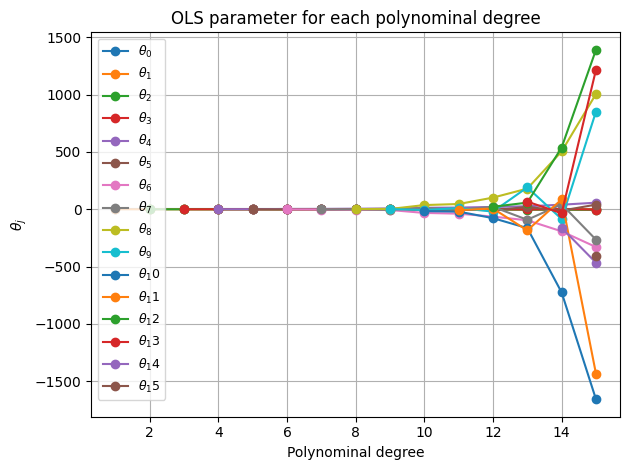

In [5]:
max_degrees = max(degrees)

for j in range(max_degrees + 1):
    theta_j = [theta[j] if j < len(theta) else np.nan for theta in theta_values]

    plt.plot(degrees, theta_j, "o-", label = rf"$\theta_{j}$")

plt.xlabel(r"Polynominal degree"); plt.ylabel(r"$\theta_j$"); plt.title(r"OLS parameter for each polynominal degree")
plt.legend(fontsize=9); plt.tight_layout();plt.grid(True); plt.show()

B: Adding Ridge regression for the Runge function
-

In [66]:

xr_train, xr_test, yr_train, yr_test = train_test_split(x, y, test_size=0.3, random_state=2026)
degree_rigde = 10
lambdas = np.logspace(-5, 2, 61)

scaler = StandardScaler()
Xtr = design_matrix(xr_train, degree_rigde)
Xtr_sc = np.copy(Xtr)
Xtr_sc[:,1:] = scaler.fit_transform(Xtr[:,1:]) 
Xte = design_matrix(xr_test, degree_rigde)
Xte_sc = np.copy(Xte)
Xte_sc[:,1:] = scaler.transform(Xte[:,1:])


I = np.eye(Xtr_sc.shape[1])
I[0,0] = 0
mse_r_train, mse_r_test = [], []
R2_r_train, R2_r_test = [], []
theta_r_values = []

for l in lambdas:

    theta_r = np.linalg.solve(Xtr_sc.T @ Xtr_sc + l*I, Xtr_sc.T@yr_train)
    theta_r_values.append(theta_r)

    yr_train_pred = Xtr_sc@ theta_r
    yr_test_pred = Xte_sc @ theta_r

    mse_r_train.append(mean_squared_error(yr_train, yr_train_pred))
    mse_r_test.append(mean_squared_error(yr_test, yr_test_pred))

    R2_r_train.append(r2_score(yr_train, yr_train_pred))
    R2_r_test.append(r2_score(yr_test, yr_test_pred))

theta_r_values = np.array(theta_r_values)

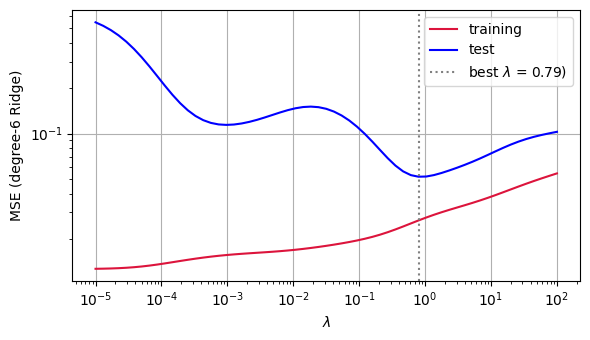

In [67]:
best = int(np.argmin(mse_r_test))
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_r_train, ms=3, color = "crimson", label="training")
plt.plot(lambdas, mse_r_test, ms=3, color = "b", label="test")
plt.axvline(lambdas[best], color="gray", ls=":", label=rf"best $\lambda$ = {lambdas[best]:.2g})") ;plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel("MSE (degree-6 Ridge)"); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

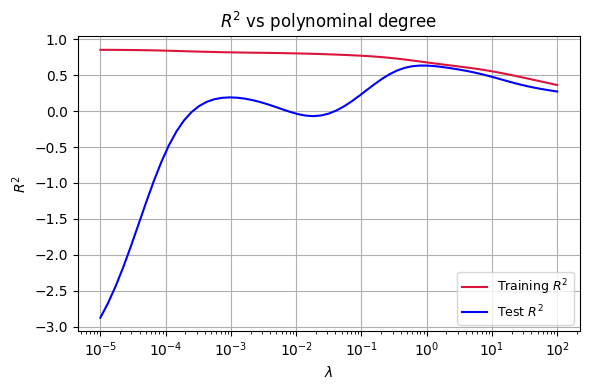

In [68]:
plt.figure(figsize=(6,4))
plt.semilogx(lambdas, R2_r_train, color = "crimson", label = "Training $R^2$")
plt.semilogx(lambdas, R2_r_test, color = "blue", label = "Test $R^2$")
plt.xlabel(fr"$\lambda$"); plt.ylabel("$R^2$"); plt.legend(fontsize=9),
plt.grid(True); plt.title("$R^2$ vs polynominal degree"); plt.tight_layout();plt.show()

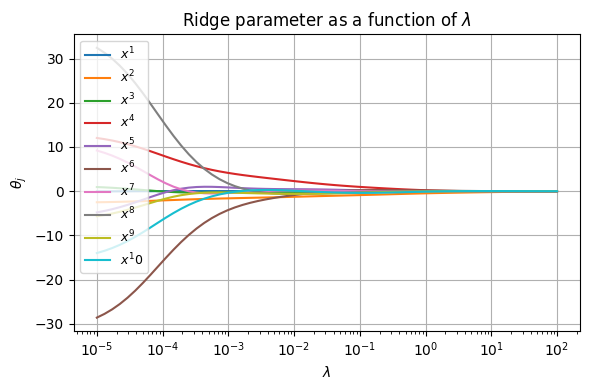

In [69]:
plt.figure(figsize=(6,4))
for j in range(1, theta_r_values.shape[1]):
    plt.semilogx(lambdas, theta_r_values[:, j], label = rf"$x^{j}$")

plt.xlabel(r"$\lambda$"); plt.ylabel(r"$\theta_j$"); plt.title(r"Ridge parameter as a function of $\lambda$")
plt.legend(fontsize=9); plt.tight_layout();plt.grid(True); plt.show()

C: The bias-variance tradeoff and the bootstrap method
-

In [70]:
xc_train, xc_test, yc_train, yc_test = train_test_split(x, y, test_size=0.3, random_state=2026)

def runge_data(degree, n=100, sigma = 0.1, seed = 2026):

    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1,1,n))    
    y = runge(x) + rng.normal(0, sigma,n)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2026)
    
    mse_tr_c, mse_te_c, theta_values = [], [], []

    for d in degree:
        scaler = StandardScaler()

        Xtr = design_matrix(x_train, d)
        Xte = design_matrix(x_test, d)

        Xtr_sc = np.copy(Xtr)
        Xte_sc = np.copy(Xte)

        Xtr_sc[:,1:] = scaler.fit_transform(Xtr[:,1:]) 
        Xte_sc[:,1:] = scaler.transform(Xte[:,1:]) 

        
        theta = np.linalg.lstsq(Xtr_sc, y_train, rcond=None)[0]
        theta_values.append(theta)

        y_train_pred = Xtr_sc @ theta
        y_test_pred = Xte_sc @ theta

        mse_tr_c.append(mean_squared_error(y_train, y_train_pred))
        mse_te_c.append(mean_squared_error(y_test, y_test_pred))
        

    return np.array(mse_tr_c), np.array(mse_te_c), theta

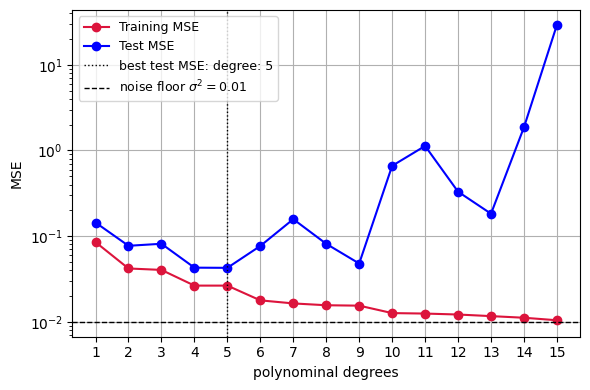

In [71]:
degrees = np.arange(1,16)
mse_tr, mse_te , theta_c = runge_data(degree=degrees, n=100, sigma = 0.1, seed = 2026)
best_degree = degrees[int(np.argmin(mse_te))]
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_tr, "o-", color = "crimson", label = "Training MSE")
plt.plot(degrees, mse_te, "o-", color = "blue", label = "Test MSE")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
plt.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
plt.xlabel("polynominal degrees"); plt.ylabel("MSE"); plt.xticks(degrees); plt.legend(fontsize=9), plt.grid(True)
plt.yscale("log"); plt.tight_layout(); plt.show()

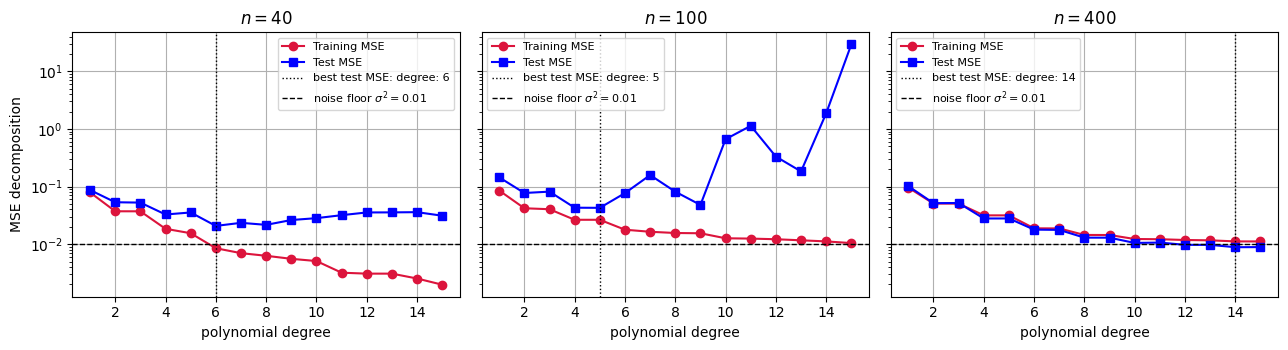

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=n_, sigma = 0.1, seed = 2026)
    best_degree = degrees[int(np.argmin(mse_te))]
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
    ax.grid(True)
    ax.legend(fontsize= 8)

axes[0].set_ylabel("MSE decomposition")

plt.tight_layout()
plt.show()

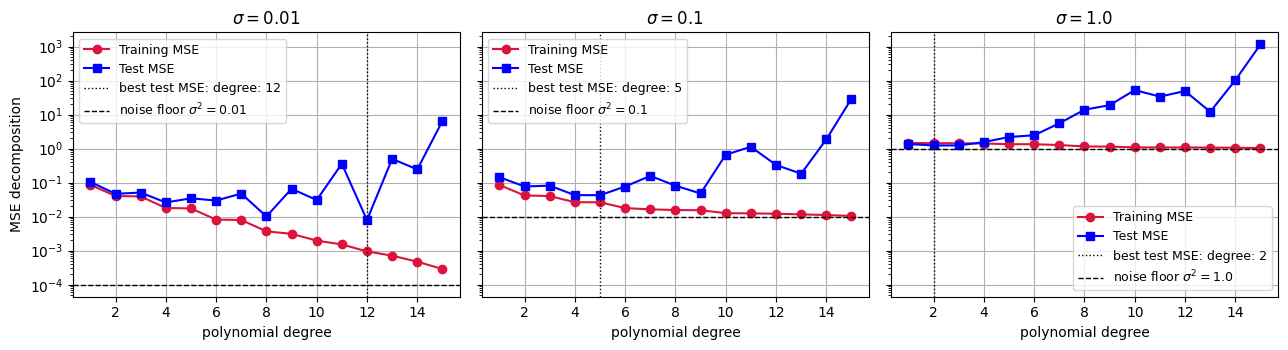

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, s_ in zip(axes, (0.01, 0.1, 1.0)):
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=100, sigma = s_, seed = 2026)
    best_degree = degrees[int(np.argmin(mse_te))]
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(s_**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = {s_}$")
    ax.set_yscale("log")
    ax.set_title(f"$\sigma = {s_}$")
    ax.set_xlabel("polynomial degree")
    ax.legend(fontsize= 9)
    ax.grid(True)

axes[0].set_ylabel("MSE decomposition")
plt.legend(fontsize= 9); plt.grid(True)
plt.tight_layout()
plt.show()

Bias-variance analasys of the runge function using the boot-starp method
-

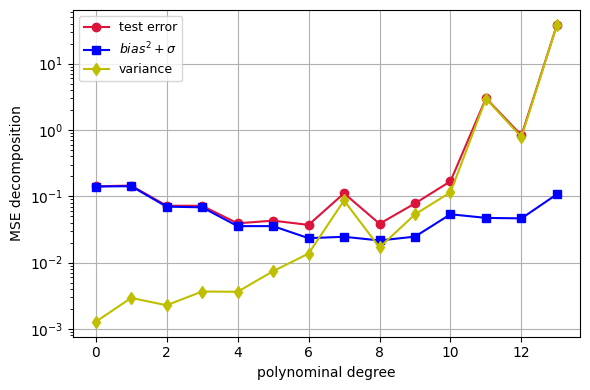

degree  0: error 0.1418  bias^2 0.1405  var 0.0013  sum 0.1418
degree  4: error 0.0392  bias^2 0.0356  var 0.0036  sum 0.0392
degree  8: error 0.0386  bias^2 0.0216  var 0.0170  sum 0.0386
degree 11: error 3.0110  bias^2 0.0473  var 2.9636  sum 3.0110
degree 13: error 38.4291  bias^2 0.1076  var 38.3215  sum 38.4291


In [111]:
np.random.seed(2026)

n, n_bootstrap, maxdegree = 100, 100, 14
rng = np.random.default_rng(2026)
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
x = np.asarray(x).reshape(-1, 1)
y = runge(x) + rng.normal(0, sigma, size = (n, 1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)

for degree in range(maxdegree):
    #model = make_pipeline(PolynomialFeatures(degree = degree),StandardScaler(), LinearRegression(fit_intercept=False))
    model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstrap))
    for i in range(n_bootstrap):
        x_, y_ = resample(x_train, y_train)
        y_pred[:,i] = model.fit(x_, y_).predict(x_test).ravel()

    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

plt.subplots(figsize=(6,4))
plt.plot(range(maxdegree), error, "o-", color = "crimson", label = "test error")
plt.plot(range(maxdegree), bias, "s-", color = "b", label = r"$bias^2 + \sigma$")
plt.plot(range(maxdegree), variance, "d-", color = "y", label = "variance")
plt.xlabel("polynominal degree"); plt.ylabel("MSE decomposition")
plt.yscale("log"); plt.legend(fontsize=9); plt.grid(True)
plt.tight_layout(); plt.show()

for d in (0, 4, 8, 11,  maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}")

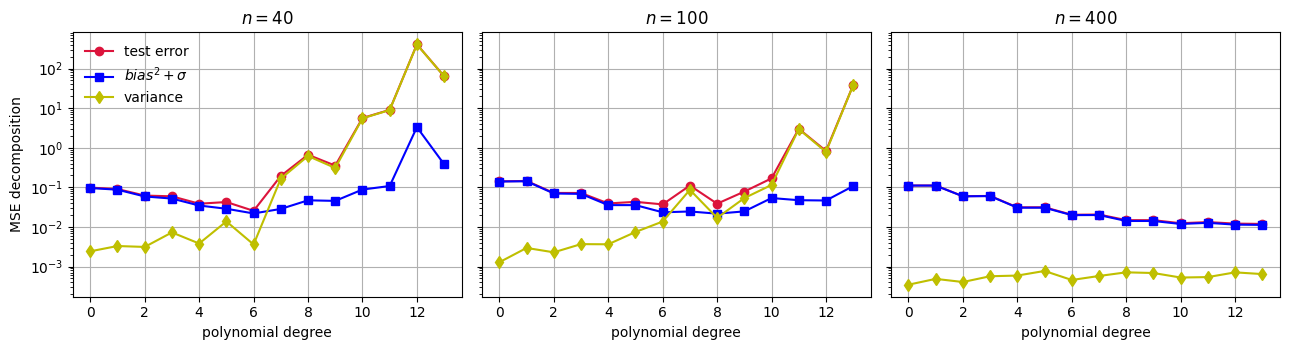

In [15]:
np.random.seed(2026)
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    '''x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)'''
    rng = np.random.default_rng(2026)
    x = np.sort(rng.uniform(-1,1,n))
    x = np.asarray(x).reshape(-1, 1)
    y = runge(x) + rng.normal(0, noise, size = (n, 1))
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                            random_state=seed)
    
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color="crimson", label="test error")
    ax.plot(range(14), b2, "s-", color="b", label=r"$bias^2 + \sigma$")
    ax.plot(range(14), var, "d-", color="y", label="variance")
    ax.set_yscale("log")
    ax.grid(True)
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [119]:
degree_fixed = 11
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 100, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                       make_model=mk)
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")

degree 11, n = 100, 100 bootstraps
  lambda       error      bias^2    variance
     OLS      9.0619      0.1080      8.9539
  0.0001      0.0422      0.0263      0.0159
     0.1      0.0307      0.0271      0.0035
      10      0.0654      0.0629      0.0025


D: Cross-validation as a resampling technique
-

In [3]:
mx_degree = 15
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)

def ols_k_fold(x,y, mx_degree, n_splits=5):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel()
    kf = KFold(n_splits, shuffle = True, random_state=2026)
    cv_mse = np.zeros(mx_degree)
    for deg in range(mx_degree):
        pipe = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y.ravel(), cv = kf, scoring="neg_mean_squared_error")
        cv_mse[deg] = scores.mean() 

    return cv_mse

CV selects degree 11 (CV-MSE 0.0211129064)
CV selects degree 11 (CV-MSE 0.0202372654)


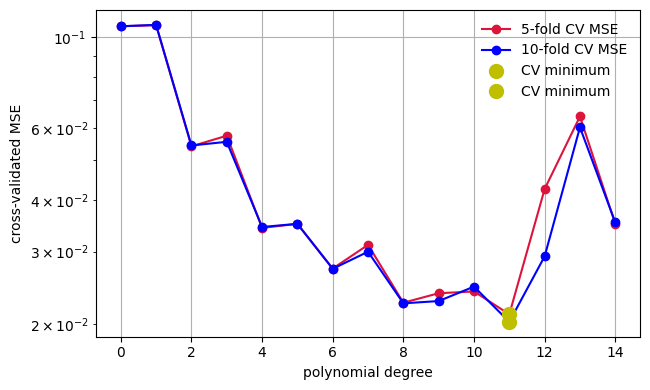

In [36]:
cv_mse5 = ols_k_fold(x,y, mx_degree, n_splits=5)
cv_mse10 = ols_k_fold(x,y, mx_degree, n_splits=10)

best_deg5 = np.argmin(cv_mse5)
best_deg10 = np.argmin(cv_mse10)

print(f"CV selects degree {best_deg5} (CV-MSE {cv_mse5[best_deg5]:.10f})")
print(f"CV selects degree {best_deg10} (CV-MSE {cv_mse10[best_deg10]:.10f})")


fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(mx_degree), cv_mse5, "o-", color='crimson', label="5-fold CV MSE")
ax.plot(range(mx_degree), cv_mse10, "o-", color='b', label="10-fold CV MSE")
ax.plot(best_deg5, cv_mse5[best_deg5], "o", color='y', ms=10, label="CV minimum")
ax.plot(best_deg10, cv_mse10[best_deg10], "o", color='y', ms=10, label="CV minimum")
ax.set_yscale("log")
ax.grid()
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False);plt.tight_layout()
plt.show()

From the figure one observes that the cv selects degree 11 as the optimal degree for both k_fold equal to 5 and 10. This is quite different from the OLS that gave 5 and the bootstrap suggested degree 6. 

In [37]:
def RIDGE_k_fold(x, y, nlambdas, lambdas, k=5, degree=12):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel()
    
    mse_kr = np.zeros(nlambdas)
    std_kr = np.zeros(nlambdas)

    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), Ridge(alpha=lmb))
        scores = cross_val_score(pipe,x, y, cv = kfold, scoring="neg_mean_squared_error")
        mse_kr[i] = np.mean(-scores)
        std_kr[i] = scores.std()
    return mse_kr, std_kr

In [44]:
rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)    # noise variance is 1
nlam = n
lambdas = np.logspace(-7, 5, n)
degrees = np.arange(1, 14)

#kf_data = np.zeros(len(degrees), len(lambdas))
kf_mse = np.zeros((len(degrees), nlam))
kf_std = np.zeros((len(degrees), nlam))

for i, deg in enumerate(degrees):
    #for j, l in enumerate(lambdas):
    kf_mse5, kf_std5 = RIDGE_k_fold(x, y, nlam, lambdas=lambdas, k=5, degree=deg)
    kf_mse[i, :] = kf_mse5
    kf_std[i, :] = kf_std5

best_i, best_j = np.unravel_index(np.argmin(kf_mse), kf_mse.shape)

best_d = degrees[best_i]
best_l = lambdas[best_j]
best_mse = kf_mse[best_i, best_j]
best_std = kf_std[best_i, best_j]

print(f"Beste grad: {best_d}")
print(f"Beste lambda: {best_l:.4g}")
print(f"Beste CV-MSE: {best_mse:.5f}")
print(f"Standardavik mellom kfoldene: {best_std:.5f}")

Beste grad: 12
Beste lambda: 2.009e-05
Beste CV-MSE: 0.02068
Standardavik mellom kfoldene: 0.00534


best lambda 2.009e-05, cross-validated MSE 0.0207
best lambda 1.15e-05, cross-validated MSE 0.0192


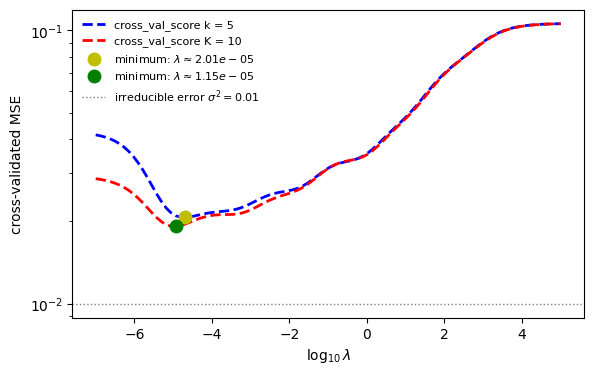

In [47]:

mse_sklearn5, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=12)
mse_sklearn10, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=10, degree=12)

best5 = np.argmin(mse_sklearn5)
best10 = np.argmin(mse_sklearn10)

print(f"best lambda {lambdas[best5]:.4g}, cross-validated MSE {mse_sklearn5[best5]:.4f}")
print(f"best lambda {lambdas[best10]:.4g}, cross-validated MSE {mse_sklearn10[best10]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))

ax.plot(np.log10(lambdas), mse_sklearn5, "--", color='b', lw=2,label="cross_val_score k = 5")
ax.plot(np.log10(lambdas), mse_sklearn10, "--", color='r', lw=2,label="cross_val_score K = 10")

ax.plot(np.log10(lambdas[best5]), mse_sklearn5[best5], "o", color='y', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best5]:.3g}$")
ax.plot(np.log10(lambdas[best10]), mse_sklearn10[best10], "o", color='green', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best10]:.3g}$")

ax.axhline(sigma**2, color="gray", lw=1, ls=":", label=rf"irreducible error $\sigma^2={sigma**2:.2f}$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False, fontsize= 8)
plt.show()

In [ ]:
#Task e hahahah lol konflikt